In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset sourse: https://catalog.data.gov/dataset/louisville-metro-ky-library-collection-inventory-5e94f 
file name : "Louisville_Library_Inventory_List.csv"

In [2]:
lv_library = pd.read_csv("Louisville_Library_Inventory_List.csv")

1. BASIC INSPECTION: .head(), .shape(), .info(), .dtypes

In [3]:
lv_library.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-","9,780,071,605,878",2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.","9,780,071,478,939",2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-","9,780,307,451,408",2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.","9,780,071,496,421",2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-","9,780,307,451,408",2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


In [4]:
lv_library.shape

(1048575, 11)

In [5]:
lv_library.info

<bound method DataFrame.info of           BibNum                                              Title  \
0         707409  Jeff Immelt and the new GE way : innovation, t...   
1        1341361           McGraw-Hill's American idioms dictionary   
2         707411  Robin rescues dinner : 52 weeks of quick-fix m...   
3        1341362  McGraw-Hill's essential ESL grammar : a handbo...   
4         707411  Robin rescues dinner : 52 weeks of quick-fix m...   
...          ...                                                ...   
1048570  1669459                        You may already be a winner   
1048571  1669506                  Bug Girl. Fury on the dance floor   
1048572  1669524                   Smack dab in the middle of maybe   
1048573  1669537                                       Anne arrives   
1048574  1669489                           A friendship to remember   

                             Author                ISBN   PublicationYear  \
0               Magee, David, 1965-   

BibNum: The unique identifier of a bibliographic record within our materials database. Materials with the same bibliographic # will generally have the same cataloging metadata, differing only in the barcode number, assigned location and anything else specific to the individual copy

Title: The name of the material

Author: The writer or creator of the material

ISBN: The International Standard Book Number is a numeric commercial book identifier that is intended to be unique. Publishers purchase ISBNs from an affiliate of the International ISBN Agency. An ISBN is assigned to each separate edition and variation of a publication

Publication Year: The year that the material was originally published

Item Type: Describes the type of material of each item, including Books, Audiobooks, Serials, DVDs, Microforms, Three Dimensional Objects, Kits, and Printed Cartographic Materials

Item Collection: Refers to the collection the material belongs to based on common themes, including but not limited to Adult Fiction, Adult Reference, Mystery, Children’s Fiction, etc.

Item Location: The library location where the material was assigned at the time the report was run

Item Price: The price, in USD, that LFPL purchased the material for


In [6]:
lv_library.dtypes

BibNum               int64
Title               object
Author              object
 ISBN               object
PublicationYear      int64
ItemType            object
ItemCollection      object
ItemLocation        object
ItemPrice          float64
ReportDate          object
ObjectId             int64
dtype: object

2. Summary Statistics

In [7]:
lv_library.describe(include='all') # numeric and categorical 

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
count,1.048575e+06,1048574,899367,886797,1.048575e+06,1048575,1048472,1048575,1.048575e+06,1048575,1.048575e+06
unique,NaN,425140,186879,395802,NaN,35,61,24,NaN,1,NaN
top,NaN,The courier-journal,"Patterson, James, 1947-","9,781,004,047,734",NaN,Book,Adult Non-Fiction,Main,NaN,2022/07/01 04:00:00+00,NaN
freq,NaN,1352,3570,379,NaN,791358,311408,222488,NaN,1048575,NaN
mean,1.010052e+06,NaN,NaN,NaN,1.979831e+03,NaN,NaN,NaN,2.156211e+01,NaN,5.242880e+05
std,6.072288e+05,NaN,NaN,NaN,2.227752e+02,NaN,NaN,NaN,2.309147e+01,NaN,3.026977e+05
min,7.000000e+00,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,0.000000e+00,NaN,1.000000e+00
25%,4.795875e+05,NaN,NaN,NaN,2.002000e+03,NaN,NaN,NaN,1.204000e+01,NaN,2.621445e+05
50%,9.764950e+05,NaN,NaN,NaN,2.010000e+03,NaN,NaN,NaN,1.795000e+01,NaN,5.242880e+05
75%,1.481470e+06,NaN,NaN,NaN,2.015000e+03,NaN,NaN,NaN,2.595000e+01,NaN,7.864315e+05


3. Data Quality Check
    - Missing values: .isnull().sum()
                     (df.isnull().sum()*100/len(df)).round(2). 
                     It sowns missing value by percentage
    - Duplicates: df.duplicated().sum()


In [8]:
(lv_library.isnull().sum()*100/len(lv_library)).round(2)

BibNum              0.00
Title               0.00
Author             14.23
 ISBN              15.43
PublicationYear     0.00
ItemType            0.00
ItemCollection      0.01
ItemLocation        0.00
ItemPrice           0.00
ReportDate          0.00
ObjectId            0.00
dtype: float64

In [9]:
lv_library.duplicated().sum()

np.int64(0)

4. Categorical Features

In [10]:
for col in lv_library.select_dtypes(include = 'object'):
    print(col, lv_library[col].nunique())
    print(lv_library[col].value_counts().head())

Title 425140
Title
The courier-journal    1352
The Blood-horse.       1028
People weekly.          909
Annual report.          588
Consumer reports.       498
Name: count, dtype: int64
Author 186879
Author
Patterson, James, 1947-             3570
Shakespeare, William, 1564-1616.    1139
Evanovich, Janet.                    856
Woods, Stuart                        855
Steel, Danielle                      833
Name: count, dtype: int64
 ISBN  395802
 ISBN 
9,781,004,047,734     379
9,780,912,289,106     230
9,781,568,372,754     195
9,781,438,070,599     154
9,780,140,280,197     129
Name: count, dtype: int64
ItemType 35
ItemType
Book        791358
Ebook        48089
DVD          47892
Serial       39573
Music CD     33385
Name: count, dtype: int64
ItemCollection 61
ItemCollection
Adult Non-Fiction         311408
Adult Fiction             102017
Electronic                 66699
Children's Non-Fiction     51585
Mystery                    44281
Name: count, dtype: int64
ItemLocation 24
Item

5. Numerical Features

array([[<Axes: title={'center': 'BibNum'}>,
        <Axes: title={'center': 'PublicationYear'}>],
       [<Axes: title={'center': 'ItemPrice'}>,
        <Axes: title={'center': 'ObjectId'}>]], dtype=object)

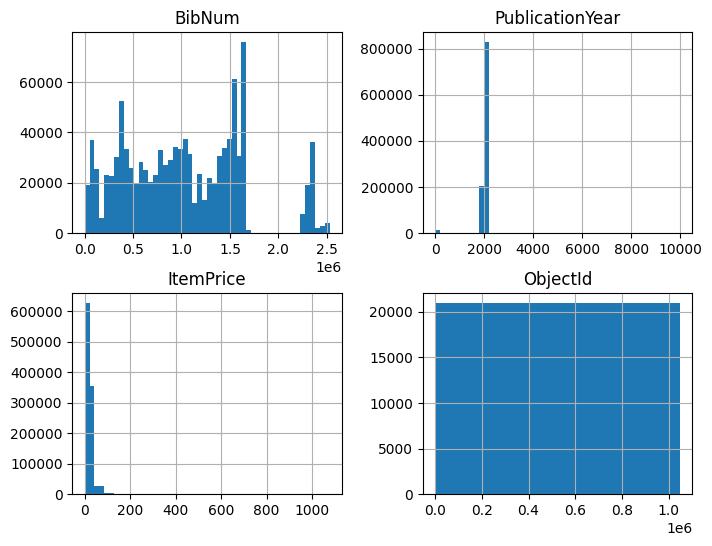

In [11]:
lv_library.hist(figsize=(8, 6), bins=50) # Distribution

<Axes: >

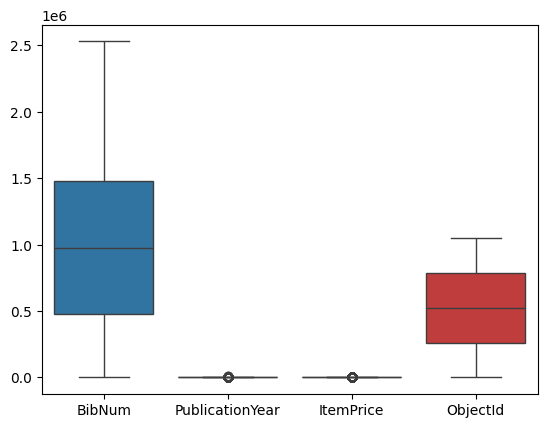

In [12]:
sns.boxplot(data=lv_library) # Boxplot for outliers

6.Relationships

In [13]:
lv_library.corr( numeric_only=True)

,BibNum,PublicationYear,ItemPrice,ObjectId
BibNum,1.000000,0.146776,-0.300336,0.564143
PublicationYear,0.146776,1.000000,-0.072632,0.108531
ItemPrice,-0.300336,-0.072632,1.000000,-0.182990
ObjectId,0.564143,0.108531,-0.182990,1.000000


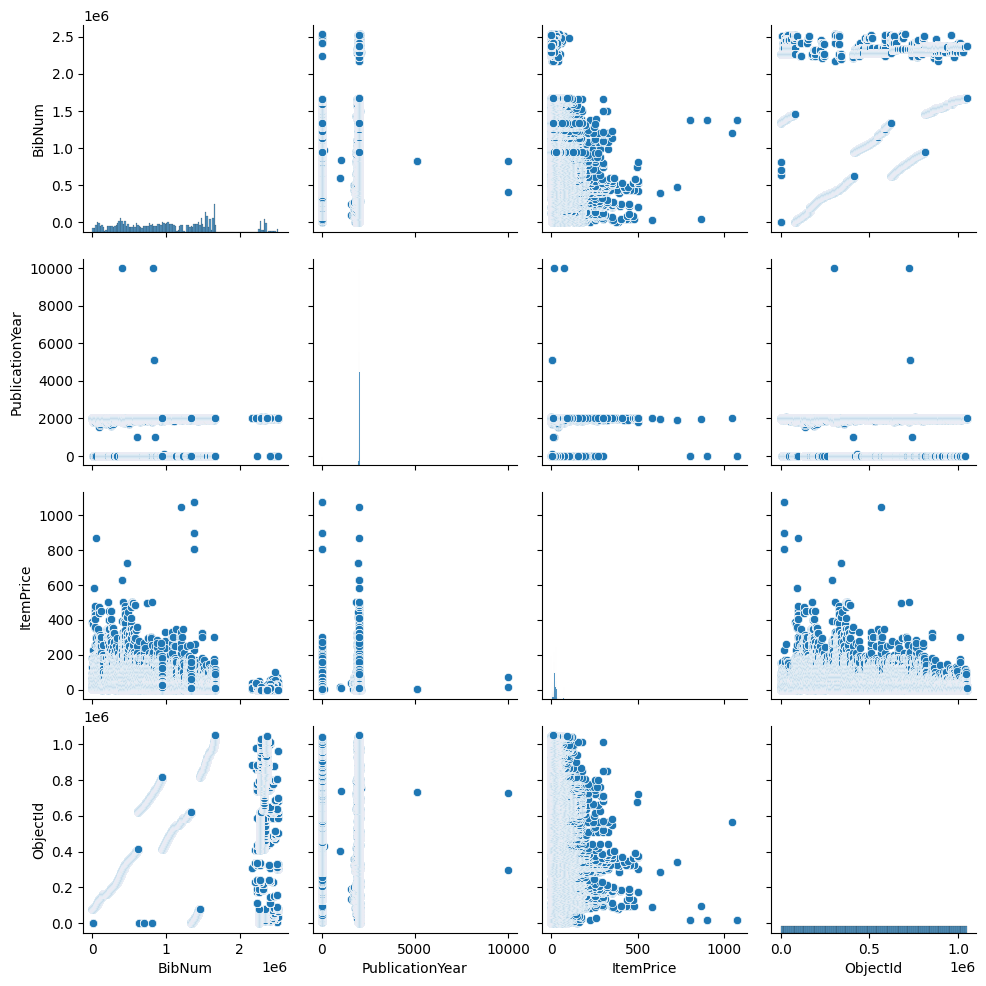

In [14]:
sns.pairplot(lv_library) #only for numeric columns